# 03 Independent validation
Written as if by a validator who did not build the models: out-of-time data only, plus a recovery check against the known synthetic DGP.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, json
from IPython.display import Image, display
pd.set_option('display.width', 200)
O = '../outputs/'
show = lambda f: display(pd.read_csv(O + f).round(4))


## 1 Discrimination (Gini / KS)

In [2]:
show('validation_discrimination.csv')

,sample,model,n,default_rate,gini,ks
0,train (2013-2021),"Hazard (Markov, macro-aware)",347590,0.0168,0.5886,0.4182
1,train (2013-2021),WoE scorecard (benchmark),347590,0.0168,0.5735,0.4148
2,train (2013-2021),Gradient boosting (challenger),347590,0.0168,0.7249,0.5363
3,validation (2022),"Hazard (Markov, macro-aware)",212210,0.0223,0.5678,0.4280
4,validation (2022),WoE scorecard (benchmark),212210,0.0223,0.5566,0.4221
5,validation (2022),Gradient boosting (challenger),212210,0.0223,0.5735,0.4275
6,out-of-time test (2023-24),"Hazard (Markov, macro-aware)",478798,0.0311,0.6459,0.4879
7,out-of-time test (2023-24),WoE scorecard (benchmark),478798,0.0311,0.6174,0.4627
8,out-of-time test (2023-24),Gradient boosting (challenger),478798,0.0311,0.6173,0.4662


## 2 Calibration (predicted vs observed 12m default rate)

,obs_year,n,predicted,observed,ratio
0,2022,212210.0,0.0229,0.0223,1.0276
1,2023,231634.0,0.0315,0.0354,0.8900
2,2024,247164.0,0.0284,0.0271,1.0492


,bureau_band,n,predicted,observed,ratio
0,A,89446.0,0.0074,0.0068,1.0855
1,B,163510.0,0.0143,0.0143,1.0004
2,C,214359.0,0.0238,0.0243,0.9807
3,D,152627.0,0.0393,0.0421,0.9350
4,E,71066.0,0.0716,0.0713,1.0044


,vintage,n,predicted,observed,ratio
0,2012,36224.0,0.0072,0.0128,0.5646
1,2013,38240.0,0.0106,0.0164,0.6504
2,2014,42235.0,0.0131,0.0127,1.0304
3,2015,47875.0,0.0173,0.0169,1.0237
4,2016,54073.0,0.0191,0.0129,1.4851
5,2017,58469.0,0.0226,0.0149,1.5149
6,2018,64759.0,0.0255,0.0199,1.2807
7,2019,68666.0,0.0277,0.0225,1.2339
8,2020,60982.0,0.0429,0.0516,0.8310
9,2021,83007.0,0.0468,0.0624,0.7494


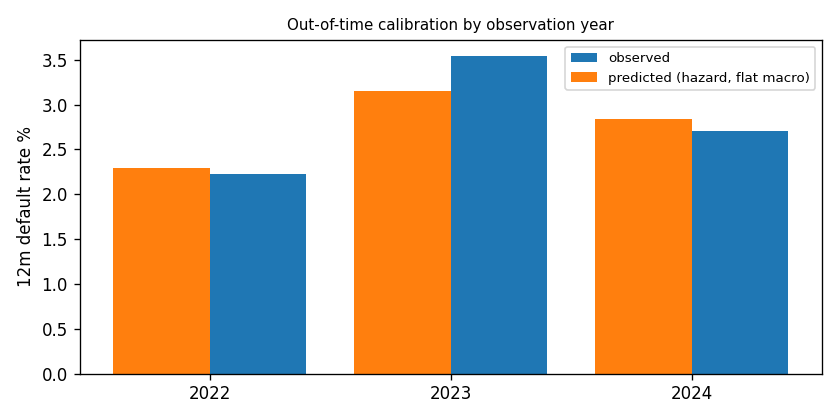

In [3]:
show('validation_calibration_year.csv'); show('validation_calibration_band.csv'); show('validation_calibration_vintage.csv'); display(Image('../docs/figures/calibration_oot.png'))

## 3 Stability (PSI / CSI)
PSI < 0.10 stable, 0.10-0.25 monitor, > 0.25 shift. Macro CSIs are expected to shift: the OOT period is a different rate/unemployment regime.

In [4]:
show('validation_stability.csv')

,item,psi,flag
0,PD score (hazard 12m),0.2907,shift
1,CSI score_z,0.0009,stable
2,CSI cltv,0.3368,shift
3,CSI dti,0.0718,stable
4,CSI age,0.4191,shift
5,CSI unemp,6.6515,shift
6,CSI ltv0,0.0003,stable
7,CSI prime_shock,3.2590,shift


## 4 Backtests

In [5]:
show('validation_ecl_backtest.csv'); show('validation_lgd_backtest.csv')

,vintage,exp_defaults,exp_loss,exposure,real_defaults,real_loss,loss_ratio_pred_vs_real
0,2012,5.5403,4.057895e+05,7.273868e+08,10.0,1.424204e+06,0.2849
1,2013,9.7276,7.157570e+05,8.487039e+08,7.0,4.848735e+05,1.4762
2,2014,11.4477,1.293251e+06,1.019077e+09,8.0,8.594107e+05,1.5048
3,2015,15.2365,1.797844e+06,1.268664e+09,11.0,2.951711e+06,0.6091
4,2016,20.4750,2.498249e+06,1.475868e+09,14.0,2.355628e+06,1.0605
5,2017,20.5458,3.053293e+06,1.731864e+09,9.0,1.533579e+06,1.9910
6,2018,26.4572,4.106430e+06,2.078886e+09,18.0,3.076308e+06,1.3349
7,2019,31.8567,6.461365e+06,2.334730e+09,24.0,7.416697e+06,0.8712
8,2020,39.1048,1.078711e+07,2.604185e+09,50.0,1.630445e+07,0.6616
9,2021,68.4386,1.990004e+07,4.015154e+09,72.0,2.277471e+07,0.8738


,band,n,predicted_lgd,realised_lgd,true_fsd
0,<60%,191,0.1528,0.1651,0.1857
1,60-80%,422,0.2105,0.1921,0.1887
2,80-100%,263,0.2679,0.2814,0.1990
3,100-120%,4,0.3401,0.3941,0.2001
4,ALL,880,0.2157,0.2138,0.1912


## 5 Recovery check vs true simulated process

,feature,fitted,true_dgp
0,score_z,-0.5483,-0.55
1,dti,4.7696,5.00
2,self_emp,0.3383,0.35
3,contract,0.4486,0.45
4,prime_shock,0.0173,0.25
5,unemp,0.1830,0.30
6,du12,-0.1150,0.00
7,probation,0.4992,0.70


,decile,fitted_p,observed,true_p
0,0,0.0010,0.0008,0.0008
1,1,0.0016,0.0010,0.0012
2,2,0.0020,0.0016,0.0016
3,3,0.0023,0.0020,0.0020
4,4,0.0027,0.0022,0.0025
5,5,0.0032,0.0029,0.0030
6,6,0.0038,0.0037,0.0038
7,7,0.0045,0.0047,0.0049
8,8,0.0057,0.0067,0.0067
9,9,0.0091,0.0134,0.0136


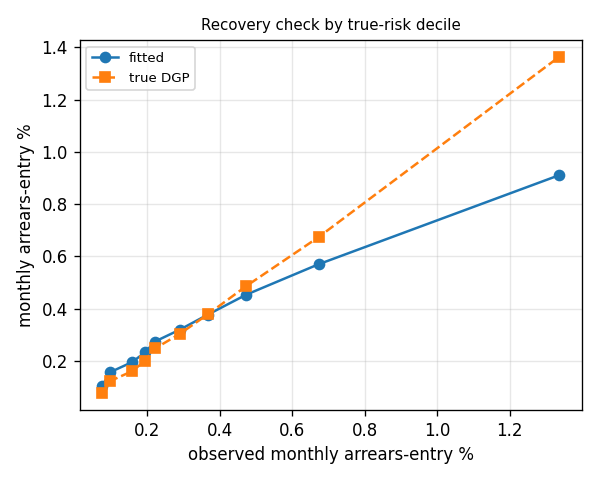

In [6]:
show('validation_recovery_coefficients.csv'); show('validation_recovery_deciles.csv'); display(Image('../docs/figures/recovery_check.png'))

## 6 Headline JSON

In [7]:
print(json.dumps(json.load(open(O + 'results.json')), indent=1)[:2500])

{
 "reporting_date": "2025-12",
 "n_loans": 30000,
 "n_open": 20939,
 "total_ead": 24342880256.0,
 "ecl_final": 289745832.45661366,
 "coverage_pct": 1.1902693083543288,
 "ecl_by_scenario": {
  "base": 281055000.7585366,
  "upside": 265028304.2285338,
  "downside": 319709679.5097338
 },
 "weights": {
  "base": 0.5,
  "upside": 0.2,
  "downside": 0.3
 },
 "stage_share": {
  "1": 0.8285244107246399,
  "2": 0.12001440674066544,
  "3": 0.05146113783121109
 },
 "gini_test": {
  "Hazard (Markov, macro-aware)": 0.6458736307585904,
  "WoE scorecard (benchmark)": 0.6173731713959008,
  "Gradient boosting (challenger)": 0.6173234503683664
 },
 "ks_test": {
  "Hazard (Markov, macro-aware)": 0.4879499907885618,
  "WoE scorecard (benchmark)": 0.4626685925550633,
  "Gradient boosting (challenger)": 0.4661615188889602
 },
 "cure_backtest": {
  "n": 1480,
  "predicted_cure_rate": 0.2238739354118781,
  "observed_cure_rate": 0.2445945945945946
 },
 "spearman_recovery": 0.8864698071268345,
 "lgd_pred": 0.2